# Scaleworm Detection Verification Lab

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook runs the YOLO "Mushroom Model" on CAMHD video frames and lets you verify each detection. Your job is to look at each cropped detection and decide: **is this a scale worm, or not?**

**Workflow:**
1. **Choose your date range** — pick which days of video to analyze
2. **Extract frames** — pull Scene 1 frames from each video (the Mushroom vent zoom)
3. **Run the detector** — YOLO finds candidate scale worms at low confidence (catches more, but includes false positives)
4. **Verify each detection** — you'll see each crop at multiple zoom levels and mark it as worm or not-worm
5. **Export** — verified true detections are packaged as a YOLO-format dataset for downstream training

</span>

## 1. Setup

In [1]:
import json
import re
import shutil
import subprocess
import zipfile
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# ── Configuration ───────────────────────────────────────────────────
# YOLO model path put mushroom.pt path here
MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
                  # "notebooks/runs/outputs/model/yolo_v26/train_v1/weights/best.pt") # in future replace with your link 

# Video archive root
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")

# Working directory for this session
WORK_DIR = Path("./verification_session")
FRAMES_DIR = WORK_DIR / "frames"
CROPS_DIR = WORK_DIR / "crops"
EXPORT_DIR = WORK_DIR / "export"

# Frame extraction parameters
SCENE1_START_SEC = 305   # Scene 1 start offset in each video
SCENE1_DURATION_SEC = 15  # Scene 1 duration
FPS = 1                  # Frames per second to extract
FRAME_W, FRAME_H = 1920, 1080

# Detection parameters
CONF_THRESHOLD = 0.1      # Low threshold to catch more candidates
MAX_BOX_SIZE = 300        # Filter out boxes larger than this (not real worms)

# Standard 3-hour cadence times (UTC)
STANDARD_TIMES = {
    "T001500", "T031500", "T061500", "T091500",
    "T121500", "T151500", "T181500", "T211500",
}

for d in [WORK_DIR, FRAMES_DIR, CROPS_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Model:     {MODEL_PATH}")
print(f"Exists:    {MODEL_PATH.exists()}")
print(f"Video root: {VIDEO_ROOT}")
print(f"Exists:    {VIDEO_ROOT.exists()}")
print(f"Work dir:  {WORK_DIR.resolve()}")
print(f"Conf threshold: {CONF_THRESHOLD}")

Model:     /home/jovyan/scaleworm-student-lab/mushroom.pt
Exists:    True
Video root: /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301
Exists:    True
Work dir:  /home/jovyan/scaleworm-student-lab/notebooks/verification_session
Conf threshold: 0.1


## 2. Choose your date range

<span style="font-family: 'Courier New', monospace;">

Run the cell below to see which dates have video available, then set your start and end dates.

</span>

In [2]:
def find_videos(video_root, start_date, end_date):
    """Find standard-cadence CAMHD videos between two dates (inclusive).

    Parameters
    ----------
    video_root : Path
        Root of the CAMHD archive (contains year/month/day subdirs).
    start_date : str
        Start date as 'YYYY-MM-DD'.
    end_date : str
        End date as 'YYYY-MM-DD'.

    Returns
    -------
    list of Path
        Sorted list of video file paths.
    """
    import datetime
    d_start = datetime.date.fromisoformat(start_date)
    d_end = datetime.date.fromisoformat(end_date)

    videos = []
    for mp4 in sorted(video_root.rglob("CAMHDA301-*.mp4")):
        m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})T(\d{6})", mp4.name)
        if not m:
            continue
        y, mo, d, time_str = m.group(1), m.group(2), m.group(3), m.group(4)
        file_date = datetime.date(int(y), int(mo), int(d))

        if file_date < d_start or file_date > d_end:
            continue

        # Only keep standard 3-hour cadence times
        if f"T{time_str}" not in STANDARD_TIMES:
            continue

        videos.append(mp4)

    return sorted(videos)


# ════════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"   # First day to analyze (YYYY-MM-DD)
END_DATE   = "2024-10-31"   # Last day to analyze (YYYY-MM-DD)

# ════════════════════════════════════════════════════════════════════

videos = find_videos(VIDEO_ROOT, START_DATE, END_DATE)

print(f"Found {len(videos)} standard-cadence videos "
      f"between {START_DATE} and {END_DATE}:\n")
for v in videos:
    print(f"  {v.name}")

Found 247 standard-cadence videos between 2024-10-01 and 2024-10-31:

  CAMHDA301-20241001T031500.mp4
  CAMHDA301-20241001T061500.mp4
  CAMHDA301-20241001T091500.mp4
  CAMHDA301-20241001T121500.mp4
  CAMHDA301-20241001T151500.mp4
  CAMHDA301-20241001T181500.mp4
  CAMHDA301-20241001T211500.mp4
  CAMHDA301-20241002T001500.mp4
  CAMHDA301-20241002T031500.mp4
  CAMHDA301-20241002T061500.mp4
  CAMHDA301-20241002T091500.mp4
  CAMHDA301-20241002T121500.mp4
  CAMHDA301-20241002T151500.mp4
  CAMHDA301-20241002T181500.mp4
  CAMHDA301-20241002T211500.mp4
  CAMHDA301-20241003T001500.mp4
  CAMHDA301-20241003T031500.mp4
  CAMHDA301-20241003T061500.mp4
  CAMHDA301-20241003T091500.mp4
  CAMHDA301-20241003T121500.mp4
  CAMHDA301-20241003T151500.mp4
  CAMHDA301-20241003T181500.mp4
  CAMHDA301-20241003T211500.mp4
  CAMHDA301-20241004T001500.mp4
  CAMHDA301-20241004T031500.mp4
  CAMHDA301-20241004T061500.mp4
  CAMHDA301-20241004T091500.mp4
  CAMHDA301-20241004T121500.mp4
  CAMHDA301-20241004T151500.mp4
  

## 3. Extract Scene 1 frames

<span style="font-family: 'Courier New', monospace;">

Each CAMHD video is ~25 minutes long. Scene 1 (305–320 seconds) is when the camera zooms in on the Mushroom vent chimney — this is where the scale worms live. We extract frames from this 15-second window at 10 fps = 150 frames per video.

</span>

In [3]:
def extract_scene1_frames(video_path, output_dir):
    """Extract Scene 1 frames from a CAMHD video using ffmpeg.

    Returns the number of frames extracted, or 0 on failure.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    # Check if already extracted
    existing = sorted(output_dir.glob("frame_*.png"))
    if len(existing) >= FPS * SCENE1_DURATION_SEC - 1:
        return len(existing)

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(SCENE1_START_SEC),
        "-i", str(video_path),
        "-t", str(SCENE1_DURATION_SEC),
        "-vf", f"fps={FPS}",
        "-q:v", "2",
        str(output_dir / "frame_%04d.png"),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    if result.returncode != 0:
        print(f"  ERROR extracting {video_path.name}: {result.stderr[-200:]}")
        return 0

    frames = sorted(output_dir.glob("frame_*.png"))
    return len(frames)


# Extract frames for all videos
total_frames = 0
video_frame_dirs = {}  # video_name -> frame_dir

for i, vpath in enumerate(videos):
    # Use video name (without extension) as subdirectory
    vid_name = vpath.stem  # e.g., CAMHDA301-20241004T001500
    frame_dir = FRAMES_DIR / vid_name
    video_frame_dirs[vid_name] = frame_dir

    n = extract_scene1_frames(vpath, frame_dir)
    total_frames += n
    print(f"  [{i+1}/{len(videos)}] {vid_name}: {n} frames")

print(f"\nTotal: {total_frames} frames from {len(videos)} videos")

  [1/247] CAMHDA301-20241001T031500: 15 frames
  [2/247] CAMHDA301-20241001T061500: 15 frames
  [3/247] CAMHDA301-20241001T091500: 15 frames
  [4/247] CAMHDA301-20241001T121500: 15 frames
  [5/247] CAMHDA301-20241001T151500: 15 frames
  [6/247] CAMHDA301-20241001T181500: 15 frames
  [7/247] CAMHDA301-20241001T211500: 15 frames
  [8/247] CAMHDA301-20241002T001500: 15 frames
  [9/247] CAMHDA301-20241002T031500: 15 frames
  [10/247] CAMHDA301-20241002T061500: 15 frames
  [11/247] CAMHDA301-20241002T091500: 15 frames
  [12/247] CAMHDA301-20241002T121500: 15 frames
  [13/247] CAMHDA301-20241002T151500: 15 frames
  [14/247] CAMHDA301-20241002T181500: 15 frames
  [15/247] CAMHDA301-20241002T211500: 15 frames
  [16/247] CAMHDA301-20241003T001500: 15 frames
  [17/247] CAMHDA301-20241003T031500: 15 frames
  [18/247] CAMHDA301-20241003T061500: 15 frames
  [19/247] CAMHDA301-20241003T091500: 15 frames
  [20/247] CAMHDA301-20241003T121500: 15 frames
  [21/247] CAMHDA301-20241003T151500: 15 frames
 

## 4. Run the YOLO detector

<span style="font-family: 'Courier New', monospace;">

We run the Mushroom Model at a low confidence threshold (0.1) to catch as many candidates as possible. This means the model will report detections it's only 10% sure about — many will be false positives, which is exactly what you'll verify in the next step.

</span>

In [4]:
!pip install ultralytics

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 62.9 MB/s eta 0:00:00:00:0100:01
Using cached ultralytics_thop-2.0.19-py3-none-any.whl (28 kB)


In [5]:
from ultralytics import YOLO
from collections import defaultdict

model = YOLO(str(MODEL_PATH))
print(f"Loaded model: {MODEL_PATH.name}")

all_detections = []

for vid_name, frame_dir in sorted(video_frame_dirs.items()):
    frames = sorted(frame_dir.glob("frame_*.png"))
    if not frames:
        continue

    # model.track() instead of model.predict()
    # persist=True keeps track IDs consistent across frames in this video
    results = model.track(
        source=[str(f) for f in frames],
        conf=CONF_THRESHOLD,
        tracker="bytetrack.yaml",
        persist=True,
        verbose=False,
        stream=True,
    )

    vid_det_count = 0
    for frame_path, result in zip(frames, results):
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy  = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()

        # track_id is None if tracking lost the object — fall back to -1
        track_ids = (
            boxes.id.cpu().numpy().astype(int)
            if boxes.id is not None
            else [-1] * len(xyxy)
        )

        for det_idx, (box, conf, tid) in enumerate(zip(xyxy, confs, track_ids)):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w > MAX_BOX_SIZE or h > MAX_BOX_SIZE:
                continue

            all_detections.append({
                "video":       vid_name,
                "frame_file":  frame_path.name,
                "frame_path":  str(frame_path),
                "det_idx":     det_idx,
                "track_id":    int(tid),       # <-- new
                "x1": float(x1), "y1": float(y1),
                "x2": float(x2), "y2": float(y2),
                "conf":        float(conf),
                "label":       None,
            })
            vid_det_count += 1

    # Reset tracker between videos so track IDs don't bleed across videos
    model.predictor = None

    print(f"  {vid_name}: {len(frames)} frames, {vid_det_count} detections")

print(f"\nTotal: {len(all_detections)} candidate detections to verify")

Loaded model: mushroom.pt
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.3 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

  CAMHDA301-20241001T031500: 15 frames, 0 detections
  CAMHDA301-20241001T061500: 15 frames, 1 detections
  CAMHDA301-20241001T091500: 15 frames, 25 detections
  CAMHDA301-20241001T121500: 15 frames, 0 detections
  CAMHDA301-20241001T151500: 15 frames, 13 detections
  CAMHDA301-20241001T181500: 15 frames, 59 detections
  CAMHDA301-20241001T211500: 15 frames, 127 detections
  CAMHDA301-20241002T001500: 15 frames, 0 detections
  CAMHDA301-20241002T031500: 15 frames, 10 detections
  CAMHDA301-20241002T061500: 15 frames, 9 detections
  CAMHDA301-20241002T091500: 15 frames, 5 detections
  CAMHDA301-20241002T1

## 5. Crop detections

<span style="font-family: 'Courier New', monospace;">

Each detection bounding box is cropped from its source frame. The crop is padded by 20 pixels on each side so you can see context around the detection.

</span>

In [6]:
PAD_PX = 20  # Context padding around each crop

# Cache loaded frames to avoid re-reading
_frame_cache = {}

def load_frame(frame_path):
    """Load a frame image, with caching."""
    if frame_path not in _frame_cache:
        _frame_cache[frame_path] = np.array(Image.open(frame_path))
        # Keep cache manageable — drop oldest if > 50 frames
        if len(_frame_cache) > 50:
            oldest = next(iter(_frame_cache))
            del _frame_cache[oldest]
    return _frame_cache[frame_path]


def crop_detection(det, pad=PAD_PX):
    """Crop a detection from its frame with padding. Returns numpy array."""
    img = load_frame(det["frame_path"])
    h, w = img.shape[:2]

    x1 = max(0, int(det["x1"]) - pad)
    y1 = max(0, int(det["y1"]) - pad)
    x2 = min(w, int(det["x2"]) + pad)
    y2 = min(h, int(det["y2"]) + pad)

    return img[y1:y2, x1:x2]


# Pre-crop all detections and save to disk
print("Cropping detections...")
for i, det in enumerate(all_detections):
    crop = crop_detection(det)
    crop_path = CROPS_DIR / f"crop_{i:06d}.png"
    Image.fromarray(crop).save(crop_path)
    det["crop_path"] = str(crop_path)

    if (i + 1) % 500 == 0 or (i + 1) == len(all_detections):
        print(f"  {i+1}/{len(all_detections)} crops saved")

_frame_cache.clear()  # Free memory
print("Done.")

Cropping detections...
  500/2518 crops saved
  1000/2518 crops saved
  1500/2518 crops saved
  2000/2518 crops saved
  2500/2518 crops saved
  2518/2518 crops saved
Done.


## 6. Verify detections

<span style="font-family: 'Courier New', monospace;">

Now the main event! For each candidate detection, you'll see:
- **Left panel**: The crop at its original pixel size (1×)
- **Center panel**: The crop scaled up 2× so you can see more detail
- **Right panel**: The crop scaled up 4× for fine detail inspection

Click **✓ Scale Worm** if it's a real worm, or **✗ Not a Worm** if it's a false detection (tube, bacterial mat, artifact, etc.). Click **Skip** if you're genuinely unsure — but try to make a call.

Your progress is saved after every decision, so you can stop and resume later.

</span>

In [7]:
# ── Load saved progress if resuming ─────────────────────────────────
SAVE_PATH = WORK_DIR / "verification_progress.json"

if SAVE_PATH.exists():
    with open(SAVE_PATH) as f:
        saved = json.load(f)
    # Restore labels
    for i, label in saved.get("labels", {}).items():
        idx = int(i)
        if idx < len(all_detections):
            all_detections[idx]["label"] = label
    print(f"Resumed progress: {len(saved.get('labels', {}))} detections already labeled")
else:
    print("Starting fresh — no saved progress found.")


def save_progress():
    """Save current labels to disk."""
    labels = {}
    for i, det in enumerate(all_detections):
        if det["label"] is not None:
            labels[str(i)] = det["label"]
    with open(SAVE_PATH, "w") as f:
        json.dump({"labels": labels}, f, indent=2)


# ── Verification widget ────────────────────────────────────────────
# Find first unlabeled detection
current_idx = [0]
for i, det in enumerate(all_detections):
    if det["label"] is None:
        current_idx[0] = i
        break

# Display areas
output_images = widgets.Output(layout=widgets.Layout(width="100%"))
output_info = widgets.Output(layout=widgets.Layout(width="100%"))
output_progress = widgets.Output(layout=widgets.Layout(width="100%"))

# Buttons
btn_worm = widgets.Button(
    description="✓ Scale Worm",
    button_style="success",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_not_worm = widgets.Button(
    description="✗ Not a Worm",
    button_style="danger",
    layout=widgets.Layout(width="180px", height="50px"),
    style={"font_weight": "bold"},
)
btn_skip = widgets.Button(
    description="⟳ Skip",
    button_style="warning",
    layout=widgets.Layout(width="120px", height="50px"),
)
btn_prev = widgets.Button(
    description="◀ Previous",
    layout=widgets.Layout(width="120px", height="50px"),
)


def show_detection(idx):
    """Display the current detection at multiple resolutions."""
    det = all_detections[idx]
    crop = np.array(Image.open(det["crop_path"]))

    with output_images:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # 1× — original size
        axes[0].imshow(crop)
        axes[0].set_title("1× (original)", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        # 2× — scaled up
        crop_2x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 2, crop.shape[0] * 2), Image.NEAREST))
        axes[1].imshow(crop_2x)
        axes[1].set_title("2× zoom", fontsize=12, fontweight="bold")
        axes[1].axis("off")

        # 4× — scaled up
        crop_4x = np.array(Image.fromarray(crop).resize(
            (crop.shape[1] * 4, crop.shape[0] * 4), Image.NEAREST))
        axes[2].imshow(crop_4x)
        axes[2].set_title("4× zoom", fontsize=12, fontweight="bold")
        axes[2].axis("off")

        fig.tight_layout()
        plt.show()

    with output_info:
        clear_output(wait=True)
        label_str = det["label"] or "unlabeled"
        label_color = {"scale_worm": "🟢", "not_worm": "🔴", "skip": "🟡"}.get(
            det["label"], "⚪")
        print(f"Detection {idx + 1} / {len(all_detections)}  |  "
              f"Conf: {det['conf']:.3f}  |  "
              f"Video: {det['video']}  |  "
              f"Frame: {det['frame_file']}  |  "
              f"Box: [{det['x1']:.0f}, {det['y1']:.0f}, {det['x2']:.0f}, {det['y2']:.0f}]  |  "
              f"Status: {label_color} {label_str}")

    update_progress()


def update_progress():
    """Show progress bar."""
    n_done = sum(1 for d in all_detections if d["label"] is not None)
    n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
    n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
    n_skip = sum(1 for d in all_detections if d["label"] == "skip")
    n_total = len(all_detections)
    pct = 100 * n_done / max(n_total, 1)

    with output_progress:
        clear_output(wait=True)
        bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
        print(f"Progress: [{bar}] {pct:.0f}%  "
              f"({n_done}/{n_total})  |  "
              f"🟢 {n_worm} worms  |  🔴 {n_not} not-worm  |  🟡 {n_skip} skipped")


def advance():
    """Move to the next unlabeled detection."""
    start = current_idx[0]
    for offset in range(1, len(all_detections) + 1):
        candidate = (start + offset) % len(all_detections)
        if all_detections[candidate]["label"] is None:
            current_idx[0] = candidate
            show_detection(current_idx[0])
            return
    # All labeled
    current_idx[0] = len(all_detections) - 1
    show_detection(current_idx[0])
    with output_info:
        print("\n🎉  ALL DETECTIONS VERIFIED!  Proceed to Step 7 to export.")


def on_worm(b):
    all_detections[current_idx[0]]["label"] = "scale_worm"
    save_progress()
    advance()

def on_not_worm(b):
    all_detections[current_idx[0]]["label"] = "not_worm"
    save_progress()
    advance()

def on_skip(b):
    all_detections[current_idx[0]]["label"] = "skip"
    save_progress()
    advance()

def on_prev(b):
    if current_idx[0] > 0:
        current_idx[0] -= 1
    show_detection(current_idx[0])


btn_worm.on_click(on_worm)
btn_not_worm.on_click(on_not_worm)
btn_skip.on_click(on_skip)
btn_prev.on_click(on_prev)

# Layout
button_bar = widgets.HBox(
    [btn_prev, btn_worm, btn_not_worm, btn_skip],
    layout=widgets.Layout(justify_content="center", gap="10px"),
)

ui = widgets.VBox([
    output_progress,
    output_images,
    output_info,
    button_bar,
])

display(ui)
show_detection(current_idx[0])

Resumed progress: 3875 detections already labeled


## 7. Summary

<span style="font-family: 'Courier New', monospace;">

Run this cell at any time to see a summary of your verification work.

</span>

In [11]:
n_total = len(all_detections)
n_worm = sum(1 for d in all_detections if d["label"] == "scale_worm")
n_not = sum(1 for d in all_detections if d["label"] == "not_worm")
n_skip = sum(1 for d in all_detections if d["label"] == "skip")
n_unlabeled = sum(1 for d in all_detections if d["label"] is None)

print("=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)
print(f"  Total detections:     {n_total:,}")
print(f"  ✓ Scale worm:         {n_worm:,} ({100*n_worm/max(n_total,1):.1f}%)")
print(f"  ✗ Not a worm:         {n_not:,} ({100*n_not/max(n_total,1):.1f}%)")
print(f"  ⟳ Skipped:            {n_skip:,}")
print(f"  ⚪ Unlabeled:          {n_unlabeled:,}")
print(f"  False positive rate:  {100*n_not/max(n_worm+n_not,1):.1f}%")
print("=" * 60)

if n_unlabeled > 0:
    print(f"\n⚠️  {n_unlabeled} detections still unlabeled. "
          "Go back to Step 6 to finish before exporting.")

n_unique_tracks = len(set(
    d["track_id"] for d in all_detections
    if d["label"] == "scale_worm" and d["track_id"] != -1
))
print(f"  🐛 Unique track IDs (worms): {n_unique_tracks:,}")
print(f"  Avg detections per track:    {n_worm / max(n_unique_tracks, 1):.1f} frames")

VERIFICATION SUMMARY
  Total detections:     2,518
  ✓ Scale worm:         2,355 (93.5%)
  ✗ Not a worm:         61 (2.4%)
  ⟳ Skipped:            102
  ⚪ Unlabeled:          0
  False positive rate:  2.5%
  🐛 Unique track IDs (worms): 30
  Avg detections per track:    78.5 frames


In [13]:
# Requires track_id to be in your all_detections list
import pandas as pd

track_df = pd.DataFrame([
    {
        'date': d['video'][10:18],   # CAMHDA301-20241001T061500
        'track_id': d['track_id'],
        'conf': d['conf'],
        'label': d['label']
    }
    for d in all_detections if d['label'] == 'scale_worm'
])

track_df['date'] = pd.to_datetime(track_df['date'], format='%Y%m%d')

summary = track_df.groupby('date').agg(
    total_detections = ('track_id', 'count'),
    unique_tracks    = ('track_id', 'nunique'),
    mean_conf        = ('conf', 'mean')
).reset_index()

summary['dets_per_track'] = summary['total_detections'] / summary['unique_tracks']
print(summary.to_string(index=False))

      date  total_detections  unique_tracks  mean_conf  dets_per_track
2024-10-01               209             11   0.647354       19.000000
2024-10-02                41              4   0.494985       10.250000
2024-10-03                84              8   0.581899       10.500000
2024-10-04               196             13   0.582170       15.076923
2024-10-05               294             18   0.594623       16.333333
2024-10-06                90             11   0.532864        8.181818
2024-10-07                53              8   0.506708        6.625000
2024-10-08               162             16   0.571452       10.125000
2024-10-09               111             17   0.516247        6.529412
2024-10-10                87              7   0.647606       12.428571
2024-10-11                40              6   0.449155        6.666667
2024-10-12                72              9   0.517497        8.000000
2024-10-13                42              5   0.275257        8.400000
2024-1

## 8. Export verified detections as YOLO dataset

<span style="font-family: 'Courier New', monospace;">

This cell builds a YOLO-format dataset zip containing only the verified true detections. The zip file can be used directly for downstream YOLO training.

**YOLO format**: Each image gets a matching `.txt` label file. Each line in the label file is:
```
class_id  center_x  center_y  width  height
```
All coordinates are normalized to [0, 1] relative to the image dimensions (1920×1080).

</span>

In [9]:
def pixel_to_yolo(x1, y1, x2, y2, img_w=FRAME_W, img_h=FRAME_H):
    """Convert pixel coords (x1, y1, x2, y2) to YOLO normalized (cx, cy, w, h)."""
    cx = ((x1 + x2) / 2) / img_w
    cy = ((y1 + y2) / 2) / img_h
    w = (x2 - x1) / img_w
    h = (y2 - y1) / img_h
    # Clamp to [0, 1]
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))
    return cx, cy, w, h


# Group verified worm detections by source frame
worm_dets = [d for d in all_detections if d["label"] == "scale_worm"]

if len(worm_dets) == 0:
    print("No verified worm detections to export!")
else:
    # Group by frame_path
    from collections import defaultdict
    frame_groups = defaultdict(list)
    for det in worm_dets:
        frame_groups[det["frame_path"]].append(det)

    # Build YOLO dataset directory
    img_dir = EXPORT_DIR / "images" / "train"
    lbl_dir = EXPORT_DIR / "labels" / "train"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    # Copy frames and write label files
    for frame_path, dets in sorted(frame_groups.items()):
        src = Path(frame_path)
        # Use video_name + frame_name for unique filenames
        video_name = dets[0]["video"]
        frame_name = dets[0]["frame_file"]
        unique_name = f"{video_name}_{frame_name}"
        stem = Path(unique_name).stem

        # Copy image
        dst_img = img_dir / unique_name
        if not dst_img.exists():
            shutil.copy2(src, dst_img)

        # Write label file
        dst_lbl = lbl_dir / f"{stem}.txt"
        with open(dst_lbl, "w") as f:
            for det in dets:
                cx, cy, w, h = pixel_to_yolo(det["x1"], det["y1"],
                                              det["x2"], det["y2"])
                f.write(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

    # Write dataset.yaml
    yaml_path = EXPORT_DIR / "dataset.yaml"
    with open(yaml_path, "w") as f:
        f.write(f"path: .\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/train\n\n")  # same split — user can reorganize
        f.write(f"nc: 1\n")
        f.write(f"names:\n")
        f.write(f"  0: scale_worm\n\n")
        f.write(f"# Verified detections: {len(worm_dets)}\n")
        f.write(f"# Source frames: {len(frame_groups)}\n")
        f.write(f"# Date range: {START_DATE} to {END_DATE}\n")
        f.write(f"# Confidence threshold: {CONF_THRESHOLD}\n")
        f.write(f"# Frame size: {FRAME_W}x{FRAME_H}\n")

    # Create zip
    zip_name = f"verified_scaleworm_dataset_{START_DATE}_to_{END_DATE}.zip"
    zip_path = WORK_DIR / zip_name

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fpath in sorted(EXPORT_DIR.rglob("*")):
            if fpath.is_file():
                arcname = fpath.relative_to(EXPORT_DIR)
                zf.write(fpath, arcname)

    zip_size_mb = zip_path.stat().st_size / 1e6

    print("=" * 60)
    print("EXPORT COMPLETE")
    print("=" * 60)
    print(f"  Verified worm detections: {len(worm_dets):,}")
    print(f"  Unique frames:            {len(frame_groups):,}")
    print(f"  YOLO dataset:             {EXPORT_DIR}")
    print(f"  Zip file:                 {zip_path}")
    print(f"  Zip size:                 {zip_size_mb:.1f} MB")
    print("=" * 60)
    print(f"\nTo use this dataset for YOLO training:")
    print(f"  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920")

EXPORT COMPLETE
  Verified worm detections: 2,355
  Unique frames:            1,163
  YOLO dataset:             verification_session/export
  Zip file:                 verification_session/verified_scaleworm_dataset_2024-10-01_to_2024-10-31.zip
  Zip size:                 4762.3 MB

To use this dataset for YOLO training:
  yolo detect train data=dataset.yaml model=yolo11m.pt epochs=20 imgsz=1920


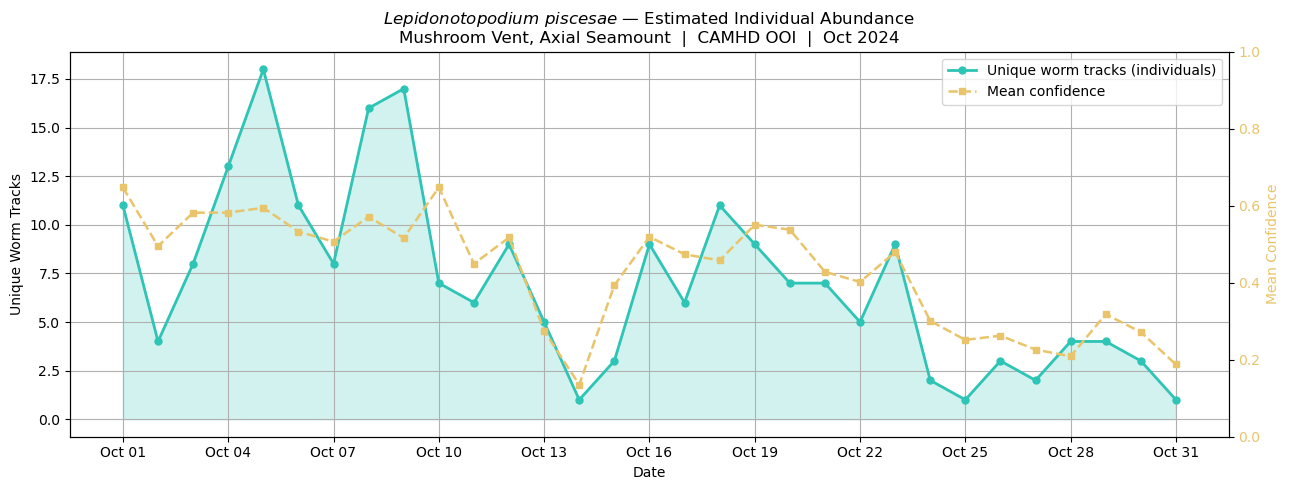

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TEAL = '#2ec4b6'
GOLD = '#e9c46a'

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(summary['date'], summary['unique_tracks'],
                alpha=0.22, color=TEAL)
ax.plot(summary['date'], summary['unique_tracks'],
        color=TEAL, linewidth=2, marker='o', markersize=5,
        label='Unique worm tracks (individuals)')

# Overlay mean confidence on right axis
ax2 = ax.twinx()
ax2.plot(summary['date'], summary['mean_conf'],
         color=GOLD, linewidth=1.8, linestyle='--',
         marker='s', markersize=4, label='Mean confidence')
ax2.set_ylabel('Mean Confidence', color=GOLD)
ax2.tick_params(axis='y', labelcolor=GOLD)
ax2.set_ylim(0, 1)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Unique Worm Tracks')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Estimated Individual Abundance'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig_unique_tracks.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd

TEAL   = '#2ec4b6'
ORANGE = '#e76f51'
GOLD   = '#e9c46a'

# Build per-video summary
video_df = pd.DataFrame([
    {
        'video':      d['video'],
        'date':       d['video'][10:18],
        'time':       d['video'][19:25],   # HHMMSS
        'track_id':   d['track_id'],
        'conf':       d['conf'],
    }
    for d in all_detections if d['label'] == 'scale_worm'
])

video_df['date']     = pd.to_datetime(video_df['date'], format='%Y%m%d')
video_df['time_fmt'] = pd.to_datetime(video_df['time'], format='%H%M%S').dt.strftime('%H:%M')
video_df['datetime'] = pd.to_datetime(
    video_df['date'].dt.strftime('%Y-%m-%d') + ' ' + video_df['time_fmt']
)

per_video = video_df.groupby(['datetime', 'date', 'time_fmt']).agg(
    total_detections = ('track_id', 'count'),
    unique_tracks    = ('track_id', 'nunique'),
    mean_conf        = ('conf',     'mean'),
).reset_index()
per_video = per_video.sort_values('datetime').reset_index(drop=True)
per_video['dets_per_track'] = (
    per_video['total_detections'] / per_video['unique_tracks']
)

print(per_video[['datetime', 'total_detections', 'unique_tracks',
                  'mean_conf', 'dets_per_track']].to_string(index=False))

           datetime  total_detections  unique_tracks  mean_conf  dets_per_track
2024-10-01 06:15:00                 1              1   0.119804        1.000000
2024-10-01 09:15:00                25              2   0.716843       12.500000
2024-10-01 15:15:00                13              1   0.224474       13.000000
2024-10-01 18:15:00                53              4   0.622652       13.250000
2024-10-01 21:15:00               117             10   0.695192       11.700000
2024-10-02 03:15:00                10              2   0.443686        5.000000
2024-10-02 06:15:00                 9              2   0.217084        4.500000
2024-10-02 09:15:00                 5              2   0.381001        2.500000
2024-10-02 21:15:00                17              2   0.705809        8.500000
2024-10-03 00:15:00                14              2   0.653216        7.000000
2024-10-03 06:15:00                 5              2   0.296597        2.500000
2024-10-03 09:15:00                 2   

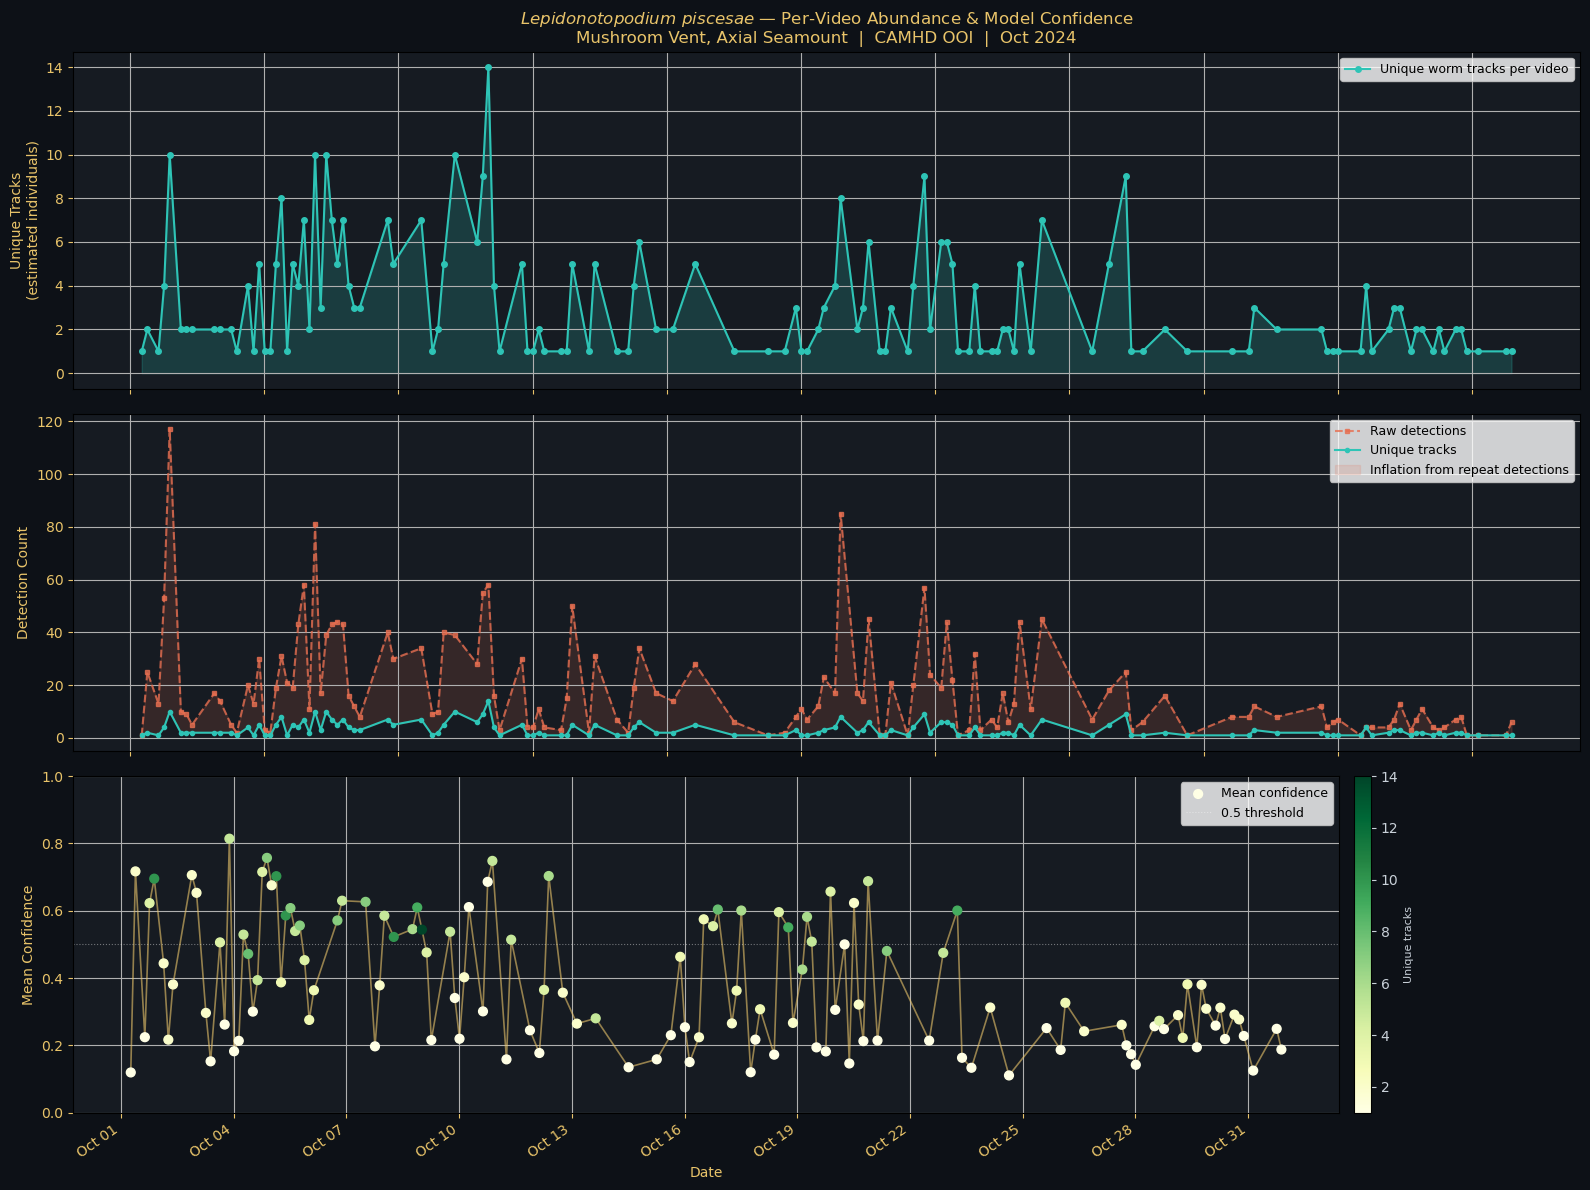

Saved: verification_session/export/fig_per_video_tracks.png


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# ── Panel 1: Unique tracks per video ─────────────────────────────────
ax = axes[0]
ax.fill_between(per_video['datetime'], per_video['unique_tracks'],
                alpha=0.2, color=TEAL)
ax.plot(per_video['datetime'], per_video['unique_tracks'],
        color=TEAL, linewidth=1.5, marker='o', markersize=4,
        label='Unique worm tracks per video')
ax.set_ylabel('Unique Tracks\n(estimated individuals)')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Per-Video Abundance & Model Confidence'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True)

# ── Panel 2: Raw detections vs unique tracks ──────────────────────────
ax = axes[1]
ax.plot(per_video['datetime'], per_video['total_detections'],
        color=ORANGE, linewidth=1.5, marker='s', markersize=3,
        linestyle='--', label='Raw detections', alpha=0.8)
ax.plot(per_video['datetime'], per_video['unique_tracks'],
        color=TEAL, linewidth=1.5, marker='o', markersize=3,
        label='Unique tracks')
ax.fill_between(per_video['datetime'],
                per_video['unique_tracks'],
                per_video['total_detections'],
                alpha=0.15, color=ORANGE,
                label='Inflation from repeat detections')
ax.set_ylabel('Detection Count')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True)

# ── Panel 3: Mean confidence per video ───────────────────────────────
ax = axes[2]
sc = ax.scatter(per_video['datetime'], per_video['mean_conf'],
                c=per_video['unique_tracks'], cmap='YlGn',
                s=40, zorder=3, label='Mean confidence')
ax.plot(per_video['datetime'], per_video['mean_conf'],
        color=GOLD, linewidth=1.2, alpha=0.6)
ax.axhline(0.5, color='white', linewidth=0.8, linestyle=':',
           alpha=0.4, label='0.5 threshold')
cbar = fig.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Unique tracks', color='#c9d1d9', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='#c9d1d9')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#c9d1d9')
ax.set_ylabel('Mean Confidence')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True)

# ── Shared x-axis formatting ──────────────────────────────────────────
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')

fig.patch.set_facecolor('#0d1117')
for a in axes:
    a.set_facecolor('#161b22')

fig.tight_layout()
for a in axes:
    a.xaxis.label.set_color('#e9c46a')
    a.yaxis.label.set_color('#e9c46a')
    a.tick_params(colors='#e9c46a')
    a.title.set_color('#e9c46a')
    legend = a.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_color('black')
        legend.get_frame().set_facecolor('white')
plt.savefig(EXPORT_DIR / 'fig_per_video_tracks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {EXPORT_DIR}/fig_per_video_tracks.png')